# Atividade Prática — Aula 5: Visualização de Dados para Decisões com Matplotlib e Seaborn

Esta atividade foi construída com base nos slides da Aula 5, cujo foco é transformar dados limpos em **gráficos que apoiem decisões**, e não em imagens decorativas. A aula reforça que o bom gráfico reduz esforço cognitivo, responde uma pergunta de negócio e precisa ser claro, comparável, simples e honesto. fileciteturn6file0

## Regras desta atividade
- Você deve **construir os códigos**.
- O notebook orienta os passos, mas não entrega a solução pronta.
- Após cada gráfico principal, escreva uma **interpretação curta** em markdown.
- O gráfico deve ser tratado como parte do seu portfólio: título, unidade, ordenação e mensagem importam. fileciteturn6file0

## Dataset da atividade
Arquivo: `vendas_brasil_clean_aula5.csv`


## 1. Preparação do ambiente

Importe as bibliotecas necessárias para trabalhar com:
- manipulação de dados
- gráficos com Matplotlib
- gráficos com Seaborn

**Sugestão:**
- `pandas`
- `matplotlib.pyplot`
- `seaborn`


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Leitura da base

Leia o arquivo `vendas_brasil_clean_aula5.csv` em um DataFrame chamado `df`.

Depois:
1. exiba as primeiras linhas
2. verifique o tamanho da base
3. confira os tipos das colunas
4. observe quais variáveis podem ser usadas para:
   - comparação
   - tendência
   - distribuição
   - relação entre métricas


In [3]:
df = pd.read_csv('vendas_brasil_clean_aula5.csv')

In [4]:
df.shape

(480, 12)

In [5]:
df.dtypes

,0
data,object
uf,object
canal_venda,object
segmento,object
categoria,object
produto,object
quantidade,int64
preco_unitario,float64
receita,float64
lucro,float64


## 3. Traduzindo a pergunta em gráfico

A aula destaca que a escolha do gráfico nunca é aleatória: a pergunta define a visualização. fileciteturn6file0

### Tarefa
Preencha em markdown pelo menos 4 exemplos no formato:

- **Pergunta do gestor:** ...
- **Variáveis (Pandas):** ...
- **Tipo de gráfico:** ...
- **Biblioteca sugerida:** ...

Use como referência a matriz mostrada nos slides:
- evolução no tempo → linha
- ranking/comparação entre grupos → barras
- variabilidade e outliers → boxplot
- correlação entre duas métricas → scatter


**Exemplos:**

- **Pergunta do gestor:** Qual canal de vendas gerou mais receita no último trimestre?
- **Variáveis (Pandas):** `canal_venda`, `receita`
- **Tipo de gráfico:** Barras horizontais
- **Biblioteca sugerida:** `seaborn` ou `matplotlib.pyplot`
---------------------------
- **Pergunta do gestor:** Como a receita se comportou ao longo do ano de 2024?
- **Variáveis (Pandas):** `mes`, `receita`
- **Tipo de gráfico:** Linha
- **Biblioteca sugerida:** `seaborn` ou `matplotlib.pyplot`
---------------------------
- **Pergunta do gestor:** A margem de lucro por segmento é consistente ou apresenta muita variabilidade?
- **Variáveis (Pandas):** `segmento`, `margem_lucro`
- **Tipo de gráfico:** Boxplot
- **Biblioteca sugerida:** `seaborn`
--------------------------
- **Pergunta do gestor:** Existe uma relação entre a quantidade de produtos vendidos e o lucro gerado?
- **Variáveis (Pandas):** `quantidade`, `lucro`
- **Tipo de gráfico:** Scatter plot
- **Biblioteca sugerida:** `seaborn` ou `matplotlib.pyplot`

## 4. Gráfico de barras horizontais — Qual canal gera mais caixa?

A missão prática do slide pede responder: **qual canal gera mais caixa?** fileciteturn6file0

### Tarefa
1. Agrupe a receita por `canal_venda`
2. Ordene os valores
3. Gere um gráfico de **barras horizontais**
4. Use rótulos e título claros
5. Certifique-se de que a visualização esteja limpa e fácil de ler

### Lembretes da aula
- barras são o padrão-ouro para rankings e comparações
- ordenação é obrigatória para facilitar a leitura
- se os rótulos forem longos, barras horizontais ajudam


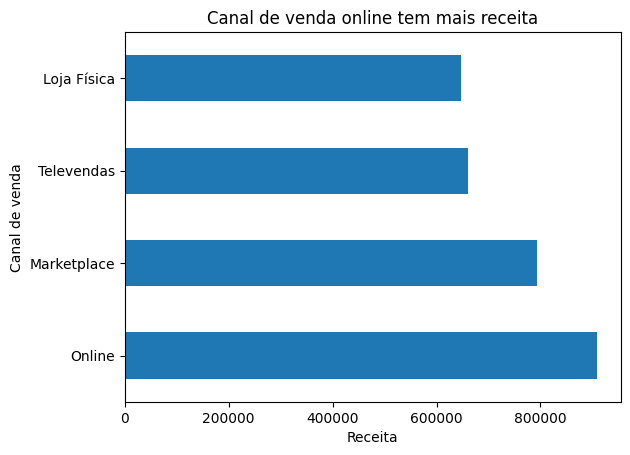

In [19]:
receita_canal = df.groupby('canal_venda')['receita'].sum().sort_values(ascending=False)
receita_canal.plot(kind='barh', title='Canal de venda online tem mais receita')
plt.ylabel('Canal de venda')
plt.xlabel('Receita')
plt.show()


### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- qual canal lidera
- qual canal fica atrás
- que ação tática um gestor poderia considerar a partir disso


De acordo os dados, o canal que lidera o volume de receitas é o canal online e o canal com o menor volume de receitas é a Loja Física. Por isso, o gestor deve aumentar investimentos no canal online e procurar formar de aumentar a receita no canal loja física

## 5. Gráfico de linha — Como é a sazonalidade ao longo dos meses?

Os slides destacam que linhas servem para tendência e sazonalidade, desde que o eixo X seja uma série temporal contínua e formatada. fileciteturn6file0

### Tarefa
1. Agrupe a `receita` por `mes`
2. Gere um gráfico de linha temporal
3. Remova ruídos visuais desnecessários
4. Use um título que diga **o que aconteceu**, não apenas o nome das colunas

### Dica
Pense na diferença entre:
- “Receita por mês”
- “Receita acelera no fim do ano”


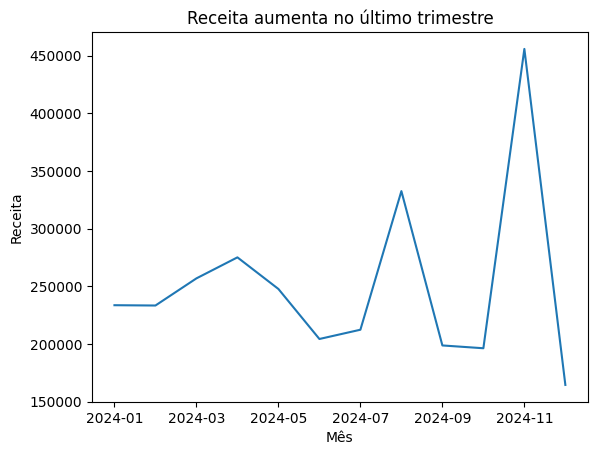

In [11]:
receita_mes = df.groupby('mes')['receita'].sum()
receita_mes.plot(kind='line', title='Receita aumenta no último trimestre')
plt.ylabel('Receita')
plt.xlabel('Mês')
plt.show()

### Insight obrigatório
Responda:
- existe sazonalidade?
- há meses de pico?
- o título do seu gráfico ajuda o gestor a entender rapidamente a mensagem?


De acordo com os dados, existe sazonalidade, com pico do volume da receita no último trimestre do ano

## 6. Boxplot — A margem oscila por segmento?

Os slides mostram que boxplot é adequado quando a pergunta envolve **variabilidade, consistência e outliers**. fileciteturn6file0

### Tarefa
1. Use `segmento` no eixo categórico
2. Use `margem_lucro` como variável numérica
3. Gere um **boxplot** com Seaborn
4. Observe dispersão, mediana e possíveis outliers

### Perguntas
- Qual segmento parece mais estável?
- Existe maior risco ou variabilidade em algum deles?
- Há outliers relevantes?


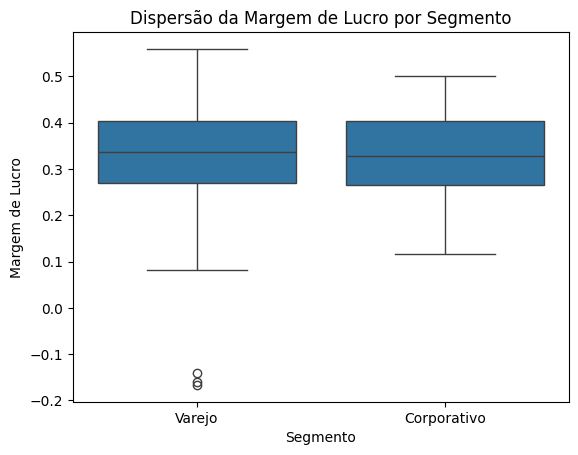

In [13]:
sns.boxplot(x='segmento', y='margem_lucro', data=df)
plt.title('Dispersão da Margem de Lucro por Segmento')
plt.xlabel('Segmento')
plt.ylabel('Margem de Lucro')
plt.show()

# O segmento que parece mais estável é o Corporativo
# Existe maior risco de variabilidade no segmento de varejo

### Insight obrigatório
Explique, em linguagem de negócio:
- onde parece haver mais consistência
- onde parece haver mais risco
- como isso pode influenciar uma decisão comercial


De acordo com os dados, o segmento que parece haver mais consistencia é o segmento corporativo, o segmento de varejo parece haver mais risco, por ter uma maior variabilidade. Por isso, uma decisão comercial no segmento de varejo pode ser mais arriscada e uma decisão comercial no segmento corporativo mais segura.

## 7. Scatter plot — Produto que fatura muito, dá lucro?

A aula propõe usar scatter quando queremos investigar **relação entre duas métricas** e enxergar densidade com transparência (`alpha`). fileciteturn6file0

### Tarefa
1. Gere um scatter com:
   - eixo X: `receita`
   - eixo Y: `lucro`
2. Use transparência para melhorar a leitura
3. Observe se existe correlação
4. Procure anomalias: pontos com alta receita e lucro ruim, por exemplo

### Perguntas
- A relação entre receita e lucro parece positiva?
- Existem exceções preocupantes?


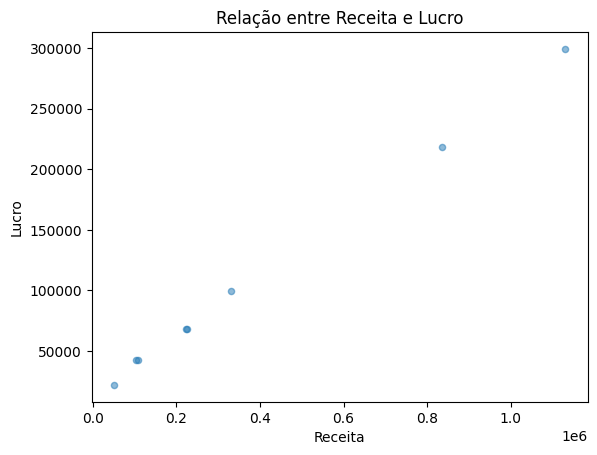

In [18]:
receita_lucro = df.groupby('produto')[['receita', 'lucro']].sum()
receita_lucro.plot(kind='scatter', x='receita', y='lucro', alpha=0.5, title='Relação entre Receita e Lucro')
plt.xlabel('Receita')
plt.ylabel('Lucro')
plt.show()

# A relação entre receita e lucro parece positiva

### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- se existe correlação visual
- se há anomalias
- que tipo de investigação o gestor deveria fazer depois desse gráfico


De acordo com os dados, existe uma correlação visual positiva entre receita e lucro: produtos com maior receita tendem a gerar maior lucro. Não parecem haver anomalias gritantes de produtos com alta receita e lucro muito baixo. No entanto, um gestor deveria investigar os produtos com menor margem de lucro para entender se há oportunidades de otimização de custos ou precificação.

## 8. Comunicação vs. decoração

A aula mostra que visualização não é estética pela estética. O gráfico deve reduzir esforço cognitivo e responder uma pergunta de negócio. fileciteturn6file0

### Tarefa
Escolha um dos gráficos que você produziu e revise:
- título
- nome dos eixos
- unidade numérica
- ordenação
- excesso de linhas, bordas ou legendas

Depois escreva:
1. O que você removeu?
2. O gráfico ficou mais fácil de interpretar?


## 9. Comparabilidade e honestidade

Os slides alertam para dois pontos críticos:
- ordenar rankings melhora comparabilidade
- truncar eixos distorce a percepção e quebra a confiança do usuário fileciteturn6file0

### Tarefa
Responda em markdown:

1. Por que ordenar barras é importante?
2. Por que truncar o eixo Y pode ser antiético ou enganoso?
3. Em que tipo de gráfico a base zero é especialmente importante?


1. Ordenar barras é crucial para facilitar a comparação visual e a identificação rápida de rankings ou diferenças significativas entre as categorias.
2. Truncar o eixo Y pode exagerar visualmente as diferenças entre os valores, fazendo com que pequenas variações pareçam muito maiores do que realmente são.
3. A base zero é especialmente importante em gráficos de barras e colunas. Nesses gráficos, o comprimento ou a altura da barra é diretamente proporcional ao valor que representa.

## 10. Galeria dos vilões

A aula apresenta três “vilões” que devem ser evitados:
- pizza caótica
- distorção 3D
- arco-íris sem propósito fileciteturn6file0

### Tarefa
Explique, em markdown:
1. Por que gráfico de pizza com muitas categorias costuma falhar?
2. Por que o 3D atrapalha comparações?
3. Por que usar muitas cores sem intenção gera confusão cognitiva?


1. Gráficos de pizza são ineficazes com muitas categorias porque o olho humano tem dificuldade em comparar tamanhos de fatias angulares, especialmente quando são pequenas e semelhantes. Distinções sutis se tornam quase impossíveis de perceber, tornando o gráfico confuso e pouco informativo para identificar proporções e rankings.
2. O uso de gráficos 3D geralmente distorce a percepção das proporções e valores. A profundidade adicionada pode fazer com que fatias de pizza ou barras pareçam maiores ou menores do que realmente são, dependendo do ângulo de visão e da perspectiva.
3. Cores têm significado e devem ser usadas com propósito. Usar muitas cores aleatoriamente ou sem um esquema lógico sobrecarrega o cérebro.

## 11. Storytelling — O gráfico não fala sozinho

Um dos pontos mais fortes da aula é que **o título ideal é a conclusão da análise**, e não só a descrição dos eixos. fileciteturn6file0

### Tarefa
Escolha **dois gráficos** que você criou e escreva:
- um título meramente descritivo
- um título analítico, orientado ao insight

Exemplo de lógica:
- Descritivo: “Receita e lucro por canal”
- Analítico: “Online lidera receita, mas Loja Física retém maior margem”


## 12. Missão prática — Case Varejo Brasil

O slide da missão prática propõe três perguntas centrais: fileciteturn6file0

1. Qual canal gera mais caixa?
2. Como é nossa sazonalidade ao longo dos meses?
3. Nosso mix corporativo é mais estável que o varejo?

### Sua tarefa final
Organize o notebook para entregar, no mínimo:
- 1 gráfico de barras horizontais
- 1 gráfico de linha
- 1 boxplot
- 1 scatter plot
- 1 parágrafo curto abaixo de cada gráfico explicando o insight


## 13. Checklist do analista profissional

Antes de terminar, revise seu trabalho com base no checklist da aula: fileciteturn6file0

- O gráfico responde claramente à pergunta original?
- Você removeu linhas, bordas e legendas que não agregam?
- Os eixos estão honestos e não distorcem a realidade?
- As cores foram usadas com intenção?
- Há um pequeno texto explicando o insight?

### Tarefa
Responda esse checklist em markdown, item por item.


## 14. Desafio extra (opcional)

Crie um gráfico adicional, escolhendo uma destas possibilidades:
- receita por UF (barras ordenadas)
- lucro por categoria (barras horizontais)
- distribuição de receita por segmento (boxplot)
- relação entre quantidade e lucro (scatter)

Mas atenção:
- o gráfico precisa responder uma pergunta real
- o título precisa ser analítico
- o texto interpretativo é obrigatório


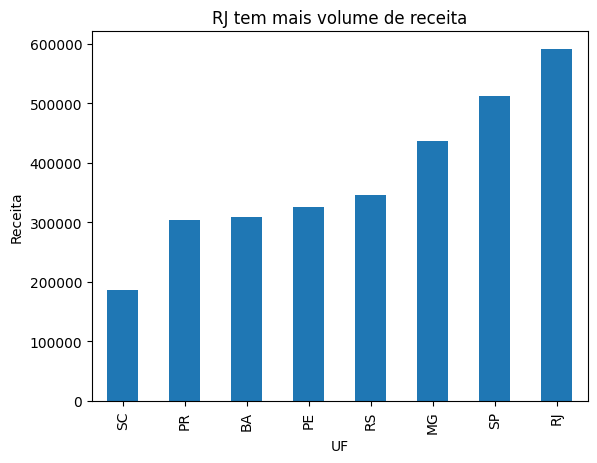

In [28]:
receita_uf = df.groupby('uf')['receita'].sum().sort_values(ascending=True)
receita_uf.plot(kind='bar', title='RJ tem mais volume de receita')
plt.ylabel('Receita')
plt.xlabel('UF')
plt.show()

De acordo com os dados, O estado RJ possui o maior volume de receita, enquanto o estado SC possui o menor volume de receita. Por isso, deve-se aumentar investimentos em RJ e buscar medidas para aumentar a receita em SC;

## 15. Entrega esperada

Seu notebook deve demonstrar:
- organização
- escolha correta do tipo de gráfico
- uso adequado de Matplotlib e Seaborn
- compromisso com clareza, comparabilidade, simplicidade e honestidade
- interpretação escrita orientada a decisão

### Mensagem principal da aula
Não basta plotar. É preciso **comunicar o sinal no meio do ruído**. fileciteturn6file0
